# Lab 7 — Video World Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab07_video_world_model/notebook.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 7**

Lab 2–3 学的是 **latent dynamics**：把图像压进低维状态 `z`，在 latent 空间里预测未来。
本 lab 把同一个问题推向它的**生成式形态** —— 直接在像素层面做 **video prediction**：
给模型前 5 帧，让它**生成**未来 10 帧。

```
frames x₁..x₅ ──CNN Encoder──▶ ConvGRU (temporal dynamics) ──CNN Decoder──▶ 预测帧 x̂₆..x̂₁₅
```

这就是 **video world model** 的最小骨架。VideoGPT、Genie、Sora 这些大规模视频模型在概念上做的是
同一件事 —— **从过去帧生成未来帧** —— 只是把 backbone 换成 diffusion / transformer，
把数据换成互联网规模的视频。你将在这个 7 万参数的小模型上，亲眼看到 video world model
的根本挑战：**long-horizon drift** —— 预测越远越模糊、越发散（Lab 10 会把它系统量化）。

## 1. Motivation：为什么视频预测是 world model 的生成式形态？

World model 的本质是**一个可以"想象"未来的模型**。Lab 2 在 latent 空间里想象（`ẑ_{t+1}` 解码回图像只是事后检查），
而 video prediction 把生成未来帧本身当作任务：

- **作为 representation learning**：要预测未来帧，模型必须内化"形状在做匀速运动、撞墙会反弹"这类物理规律 —— 预测是学习世界结构的脚手架；
- **作为 generative world model**：Genie / Sora 的思路是，从海量视频中学会"世界如何演化"，模型本身就成为一个可交互、可采样的模拟器。

但视频预测有两个根本性困难，本 lab 会让它们无处遁形：

1. **多模态未来（multimodal futures）**：同一个过去可以有很多合理的未来。用 MSE / BCE 训练的确定性模型只能输出"所有可能未来的平均" —— 表现为**模糊（blurriness）**；
2. **Compounding error / drift**：预测帧被喂回模型作为下一步输入，每一点小误差都被放大 —— 表现为**rollout 越长越发散**。

> **教学落点：** 视频预测是 world model 的生成式形态；long-horizon drift 是它的根本挑战（连接 Lab 10）。

## 2. Setup

**Why this cell exists:** 依赖只有 PyTorch（CPU 足够）、NumPy、Matplotlib、imageio（存 GIF），Colab 已全部预装；本地缺失时自动安装。全部实验在笔记本 CPU 上几分钟内跑完。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import imageio.v2 as imageio
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.path import Path as MplPath

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu")

torch 2.8.0 | device: cpu


## 3. Environment & Dataset：Moving Shapes

**Why not Moving MNIST:** Moving MNIST 需要下载 ~800MB 数据；而我们只需要"多个物体按惯性运动 + 撞墙反弹"这一最小物理。
同一个模拟器思路（Lab 0/2/10），代码内直接生成 **Moving Shapes**：

- 每段视频 3 个形状 —— **circle / square / triangle**，用灰度 1.0 / 0.75 / 0.5 区分身份；
- 每个形状有随机的初始位置、方向与速度，撞墙时**弹性反弹**；
- 每段 **16 帧、48×48 灰度**；前 `CTX=5` 帧作为 context 输入，模型预测未来 `FUT=10` 帧（最后 1 帧留作 buffer）。

任务定义：**input frames 1–5 → predict frames 6–15**。这是 video prediction 文献里的标准设定（Srivastava et al. 2015 的 "unsupervised learning of video representations"）。

In [2]:
SIZE, T = 48, 16          # 帧分辨率、每段视频帧数
CTX, FUT = 5, 10          # context 帧数 / 预测帧数（第 16 帧留作 buffer）
N_TRAIN, N_TEST = 768, 128

GRID = np.stack(np.meshgrid(np.arange(SIZE), np.arange(SIZE), indexing="ij"), -1).reshape(-1, 2)

def draw_circle(img, x, y, r, v):
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]
    m = (xx - x) ** 2 + (yy - y) ** 2 <= r * r
    img[m] = np.maximum(img[m], v)

def draw_square(img, x, y, r, v):
    x0, x1 = int(max(0, x - r)), int(min(SIZE, x + r + 1))
    y0, y1 = int(max(0, y - r)), int(min(SIZE, y + r + 1))
    img[y0:y1, x0:x1] = np.maximum(img[y0:y1, x0:x1], v)

def draw_triangle(img, x, y, r, v):
    pts = np.array([[x, y - r], [x - 0.9 * r, y + 0.7 * r], [x + 0.9 * r, y + 0.7 * r]])
    m = MplPath(pts).contains_points(GRID).reshape(SIZE, SIZE)
    img[m] = np.maximum(img[m], v)

DRAW = [draw_circle, draw_square, draw_triangle]
GRAY = [1.0, 0.75, 0.5]   # circle 最亮，triangle 最暗 —— 身份编码在灰度里

def make_video(rng, speed=1.0):
    # 3 个形状：随机位置 / 方向 / 速度，弹性撞墙反弹
    shapes = []
    for i in range(3):
        m = 7  # 出生边距
        pos = rng.uniform(m, SIZE - 1 - m, size=2)
        ang = rng.uniform(0, 2 * np.pi)
        sp = rng.uniform(1.0, 2.0) * speed
        shapes.append(dict(kind=i, pos=pos, r=rng.uniform(3.5, 5.5),
                           vel=sp * np.array([np.cos(ang), np.sin(ang)])))
    frames = np.zeros((T, SIZE, SIZE), np.float32)
    for t in range(T):
        for s in shapes:
            DRAW[s["kind"]](frames[t], s["pos"][0], s["pos"][1], s["r"], GRAY[s["kind"]])
            s["pos"] += s["vel"]
            for d in range(2):  # 弹性反弹：位置折返，速度反向
                lo, hi = s["r"], SIZE - 1 - s["r"]
                if s["pos"][d] < lo: s["pos"][d] = 2 * lo - s["pos"][d]; s["vel"][d] *= -1
                if s["pos"][d] > hi: s["pos"][d] = 2 * hi - s["pos"][d]; s["vel"][d] *= -1
    return frames

t0 = time.time()
rng = np.random.default_rng(0)
train_np = np.stack([make_video(rng) for _ in range(N_TRAIN)])
test_np = np.stack([make_video(np.random.default_rng(1000)) for _ in range(N_TEST)])
X_tr = torch.from_numpy(train_np).unsqueeze(2)   # (N, T, 1, 48, 48)
X_te = torch.from_numpy(test_np).unsqueeze(2)
print(f"train {tuple(X_tr.shape)}  test {tuple(X_te.shape)}  generated in {time.time() - t0:.1f}s")

train (768, 16, 1, 48, 48)  test (128, 16, 1, 48, 48)  generated in 0.6s


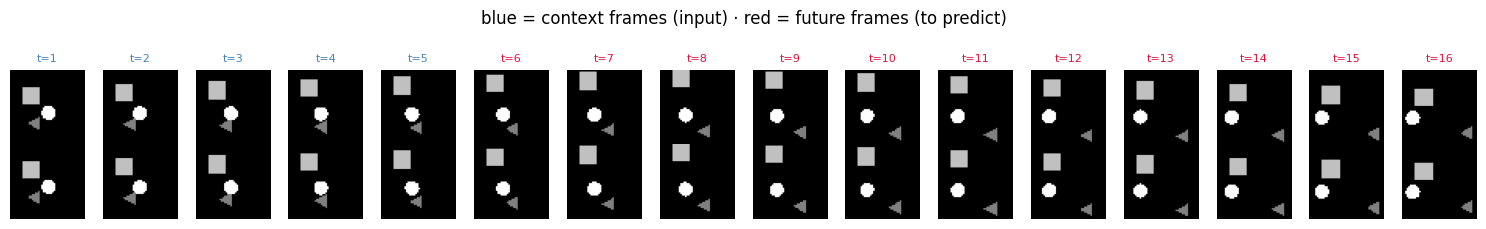

In [3]:
# 两段样例视频：每行 16 帧（前 5 帧 = context，之后是未来）
fig, axes = plt.subplots(2, T, figsize=(15, 2.2))
for r in range(2):
    for t in range(T):
        axes[r, t].imshow(test_np[r, t], cmap="gray", vmin=0, vmax=1)
        axes[r, t].axis("off")
        if r == 0:
            axes[r, t].set_title(f"t={t+1}", fontsize=8,
                                 color="steelblue" if t < CTX else "crimson")
fig.suptitle("blue = context frames (input) · red = future frames (to predict)", y=1.02)
plt.tight_layout(); plt.show()

## 4. Build the Model：CNN Encoder → ConvGRU → Decoder

**Why this architecture:** 视频预测需要同时记住"**什么**在哪里"和"**如何**运动"。
我们把 Lab 2 的 Encoder–Dynamics–Decoder 骨架升级为时空版本：

- **Encoder**：两层 stride-2 conv，把 48×48 帧压成 32 通道的 12×12 特征图 —— 保留空间结构（不 flatten）；
- **ConvGRU**（手写在下面，核心只有 4 行）：在特征图上做时间动力学。GRU 的 update/reset gate 全部用 3×3 卷积实现，因此 hidden state 本身就是一张"空间记忆图"：

$$z_t = \sigma(W_z * [x_t, h_{t-1}]), \quad r_t = \sigma(W_r * [x_t, h_{t-1}])$$
$$n_t = \tanh(W_n * [x_t,\; r_t \odot h_{t-1}]), \quad h_t = (1 - z_t) \odot n_t + z_t \odot h_{t-1}$$

- **Decoder**：两层 transposed conv，把 hidden state 解回 48×48 帧（输出 logits）。

这正是 ConvLSTM（Shi et al. 2015, precipitation nowcasting）的 GRU 简化版；整个模型只有 **~7 万参数**，纯 CPU 可训。

In [4]:
H_CH = 32   # 特征图通道数（12×12 空间分辨率）

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(),      # 48 -> 24
            nn.Conv2d(16, H_CH, 3, 2, 1), nn.ReLU(),   # 24 -> 12
        )
    def forward(self, x):
        return self.net(x)

class ConvGRUCell(nn.Module):
    # 手写 ConvGRU：gate 用 3×3 conv，hidden state 是 (B, H_CH, 12, 12) 的空间记忆
    def __init__(self, in_ch, hid_ch):
        super().__init__()
        self.gates = nn.Conv2d(in_ch + hid_ch, 2 * hid_ch, 3, 1, 1)  # update z / reset r
        self.cand = nn.Conv2d(in_ch + hid_ch, hid_ch, 3, 1, 1)       # candidate n
    def forward(self, x, h):
        z, r = torch.sigmoid(self.gates(torch.cat([x, h], dim=1))).chunk(2, dim=1)
        n = torch.tanh(self.cand(torch.cat([x, r * h], dim=1)))
        return (1 - z) * n + z * h

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(H_CH, 16, 4, 2, 1), nn.ReLU(),  # 12 -> 24
            nn.ConvTranspose2d(16, 1, 4, 2, 1),                # 24 -> 48，raw logits
        )
    def forward(self, h):
        return self.net(h)

enc, gru, dec = Encoder(), ConvGRUCell(H_CH, H_CH), Decoder()
n_params = sum(p.numel() for m in (enc, gru, dec) for p in m.parameters())
print(f"parameters: {n_params:,}  (tiny — CPU-friendly)")

def predict_future(x, enc, gru, dec):
    # x: (B, T, 1, H, W)。前 CTX 帧 warmup，之后 autoregressive rollout FUT 步：
    # 每一步 decode 出预测帧，再 re-encode 喂回 GRU（模型吃自己的预测 —— 训练即部署形态）
    B = x.shape[0]
    h = torch.zeros(B, H_CH, SIZE // 4, SIZE // 4, device=x.device)
    for t in range(CTX):
        h = gru(enc(x[:, t]), h)
    preds, cur = [], x[:, CTX - 1]
    for t in range(FUT):
        logits = dec(h)
        preds.append(logits)
        cur = torch.sigmoid(logits)          # 预测帧作为下一步输入（open-loop）
        h = gru(enc(cur), h)
    return torch.stack(preds, dim=1)         # (B, FUT, 1, H, W) logits

parameters: 68,657  (tiny — CPU-friendly)


## 5. Train：warmup + autoregressive rollout loss

**Why train this way:** 两种常见训练策略 ——

- **Teacher forcing**：每一步都喂真实帧。单步 loss 漂亮，但部署时模型吃的是自己的预测 —— 训练/测试输入分布不一致（**exposure bias**），rollout 几步就崩；
- **本 lab 的做法**：只用前 5 帧真实帧做 warmup，之后**全程让模型吃自己的预测**，loss 直接打在全部 10 步预测帧上。训练分布 = 部署分布，模型被迫学会"在自己的误差下继续走"。

损失用 `BCEWithLogitsLoss` + `pos_weight`：亮像素只占画面 ~2%，不加权模型会躺平输出全黑（与 Lab 2 同一教训：sparse targets need loss reweighting）。

step  100/600  rollout-BCE 0.5413


step  200/600  rollout-BCE 0.5102


step  300/600  rollout-BCE 0.4978


step  400/600  rollout-BCE 0.4677


step  500/600  rollout-BCE 0.4476


step  600/600  rollout-BCE 0.4245
trained in 105.2s on CPU


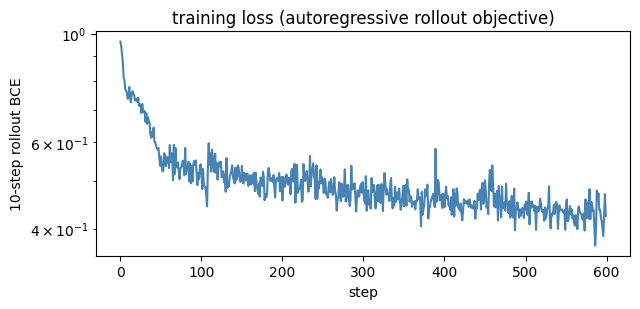

In [5]:
params = list(enc.parameters()) + list(gru.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(params, lr=3e-3)
crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(5.0))

BATCH, STEPS = 16, 600
rng = np.random.default_rng(1)
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = rng.choice(len(X_tr), BATCH, replace=False)
    xb = X_tr[idx]
    pred = predict_future(xb, enc, gru, dec)
    loss = crit(pred, xb[:, CTX:CTX + FUT])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d}/{STEPS}  rollout-BCE {loss.item():.4f}")

print(f"trained in {time.time() - t0:.1f}s on CPU")

plt.figure(figsize=(6.5, 3.2))
plt.plot(losses, color="steelblue")
plt.xlabel("step"); plt.ylabel("10-step rollout BCE"); plt.yscale("log")
plt.title("training loss (autoregressive rollout objective)")
plt.tight_layout(); plt.show()

## 6. Visualize：Ground Truth vs Prediction

**先看定性结果。** 下面每个 episode 两行：**上 = Ground Truth，下 = Prediction**（左 5 列是共同的 context 帧）。
注意观察三个渐变：预测帧**先对、再糊、后散** —— 形状的位置起初是对的，随后边缘软化（不确定性平均化），最后多个形状糊成一团。

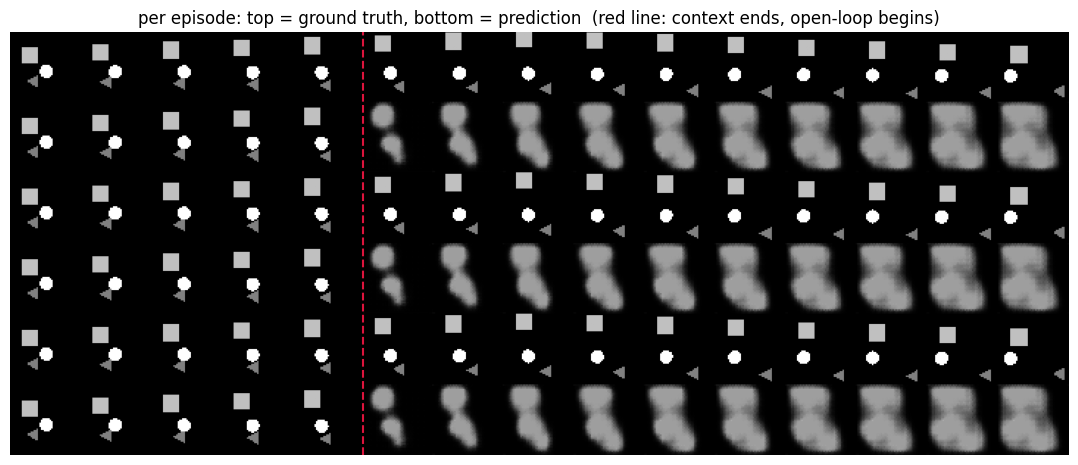

saved assets/gt_vs_pred.png and assets/prediction_rollout.gif


In [6]:
enc.eval(); gru.eval(); dec.eval()

with torch.no_grad():
    xb = X_te[:3]
    pred = torch.sigmoid(predict_future(xb, enc, gru, dec)).numpy()

rows = []
for b in range(3):
    ctx = xb[b, :CTX, 0].numpy()
    gt = xb[b, CTX:CTX + FUT, 0].numpy()
    pr = pred[b, :, 0]
    rows.append(np.concatenate(list(ctx) + list(gt), axis=1))
    rows.append(np.concatenate(list(ctx) + list(pr), axis=1))
grid = np.concatenate(rows, axis=0)

plt.figure(figsize=(15, 5.5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axvline(CTX * SIZE - 0.5, color="crimson", lw=1.5, ls="--")  # context | future 分界
plt.axis("off")
plt.title("per episode: top = ground truth, bottom = prediction  (red line: context ends, open-loop begins)")
plt.savefig("assets/gt_vs_pred.png", dpi=110, bbox_inches="tight")
plt.show()

# 存一段 side-by-side GIF：左 GT 右预测，同步播放
b = 0
ctx = xb[b, :CTX, 0].numpy()
gt = xb[b, CTX:CTX + FUT, 0].numpy()
pr = pred[b, :, 0]
side_by_side = [np.concatenate([ctx[t], ctx[t]], axis=1) for t in range(CTX)] + \
               [np.concatenate([gt[t], pr[t]], axis=1) for t in range(FUT)]
imageio.mimsave("assets/prediction_rollout.gif",
                [(f * 255).astype(np.uint8) for f in side_by_side], duration=0.3)
print("saved assets/gt_vs_pred.png and assets/prediction_rollout.gif")

fig = plt.figure(figsize=(4, 2))
plt.axis("off")
_im = plt.imshow(side_by_side[0], cmap="gray", vmin=0, vmax=1)
def _upd(i):
    _im.set_data(side_by_side[i]); return [_im]
_anim = FuncAnimation(fig, _upd, frames=len(side_by_side), interval=300, blit=True)
plt.close(fig)
HTML(_anim.to_jshtml())

## 7. Evaluate：逐帧误差曲线与 rollout degradation

**Why quantify it:** 定性图已经能看出"越长越糊"，但 world model 的部署质量需要曲线说话。
在整个 test set 上做 open-loop rollout，统计**第 k 步预测帧与 GT 的 MSE**：

- **1-step**：接近 supervised prediction，误差最低；
- **5-step**：误差开始累积，形状仍可辨认；
- **10-step**：误差约为 1-step 的数倍，预测已近"拖影"。

这条曲线就是 **compounding error / drift** 的直接度量（Lab 2 的 latent 版本、Lab 10 的 OOD 版本都是同一现象）。

step:            1        2        3        4        5        6        7        8        9       10
pixel MSE: 0.02779  0.05028  0.07392  0.08704  0.10074  0.11395  0.12460  0.13571  0.14747  0.15340

1-step MSE 0.02779 | 5-step 0.10074 (3.6×) | 10-step 0.15340 (5.5×)


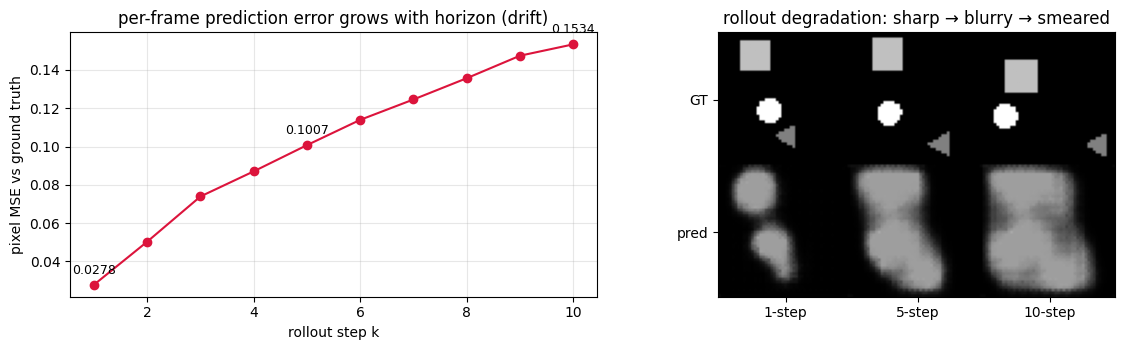

saved assets/rollout_degradation.png


In [7]:
with torch.no_grad():
    err_per_step = np.zeros(FUT)
    all_pred = []
    for i in range(0, len(X_te), 32):
        xb = X_te[i:i + 32]
        p = torch.sigmoid(predict_future(xb, enc, gru, dec))
        err_per_step += ((p - xb[:, CTX:CTX + FUT]) ** 2).mean(dim=(0, 2, 3, 4)).numpy() * len(xb)
        if i == 0:
            all_pred = p.numpy()
err_per_step /= len(X_te)

print("step:      " + "  ".join(f"{k+1:7d}" for k in range(FUT)))
print("pixel MSE: " + "  ".join(f"{e:.5f}" for e in err_per_step))
print(f"\n1-step MSE {err_per_step[0]:.5f} | 5-step {err_per_step[4]:.5f} "
      f"({err_per_step[4]/err_per_step[0]:.1f}×) | 10-step {err_per_step[9]:.5f} "
      f"({err_per_step[9]/err_per_step[0]:.1f}×)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(range(1, FUT + 1), err_per_step, "o-", color="crimson")
for k in [0, 4, 9]:
    axes[0].annotate(f"{err_per_step[k]:.4f}", (k + 1, err_per_step[k]),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
axes[0].set_xlabel("rollout step k"); axes[0].set_ylabel("pixel MSE vs ground truth")
axes[0].set_title("per-frame prediction error grows with horizon (drift)")
axes[0].grid(alpha=0.3)

# rollout degradation montage：同一 episode 的 1 / 5 / 10-step 预测帧 vs GT
sel = [0, 4, 9]
b = 1
gt = X_te[b, CTX:CTX + FUT, 0].numpy()
row_gt = np.concatenate([gt[k] for k in sel], axis=1)
row_pr = np.concatenate([all_pred[b, k, 0] for k in sel], axis=1)
axes[1].imshow(np.concatenate([row_gt, row_pr], axis=0), cmap="gray", vmin=0, vmax=1)
axes[1].set_xticks([(i + 0.5) * SIZE for i in range(3)])
axes[1].set_xticklabels(["1-step", "5-step", "10-step"])
axes[1].set_yticks([SIZE // 2, 3 * SIZE // 2]); axes[1].set_yticklabels(["GT", "pred"])
axes[1].set_title("rollout degradation: sharp → blurry → smeared")
plt.tight_layout()
plt.savefig("assets/rollout_degradation.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved assets/rollout_degradation.png")

## 8. Experiment：fast-motion stress test（漂移 × 分布偏移）

**Guided experiment:** 模型只见过 speed ∈ [1, 2] 的运动。现在不改模型、不重新训练，
只把测试集的速度 **×2.5**（mild OOD —— 同一种物理，更快的运动），重跑同一条误差曲线：

- 预测：1-step 误差就会明显升高（更快的运动 = 更大的帧间位移 = 更难的外推），且 drift 增长更陡；
- 这就是 Lab 10 的预告：**one-step 退化看似温和，multi-step rollout 会把它放大成失效**。

✏️ *试一试：把 `SPEED_TEST` 从 2.5 改成 1.0（ID 对照）或 4.0（strong OOD），观察曲线形态如何过渡。*

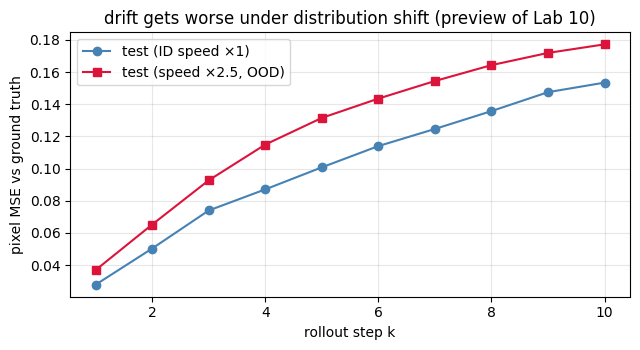

ID   : 1-step 0.02779 → 10-step 0.15340
×2.5: 1-step 0.03689 → 10-step 0.17719
saved assets/speed_stress.png


In [8]:
SPEED_TEST = 2.5
test_fast = torch.from_numpy(
    np.stack([make_video(np.random.default_rng(2000 + i), speed=SPEED_TEST)
              for i in range(N_TEST)])).unsqueeze(2)

with torch.no_grad():
    err_fast = np.zeros(FUT)
    for i in range(0, len(test_fast), 32):
        xb = test_fast[i:i + 32]
        p = torch.sigmoid(predict_future(xb, enc, gru, dec))
        err_fast += ((p - xb[:, CTX:CTX + FUT]) ** 2).mean(dim=(0, 2, 3, 4)).numpy() * len(xb)
err_fast /= len(test_fast)

plt.figure(figsize=(6.5, 3.6))
plt.plot(range(1, FUT + 1), err_per_step, "o-", color="steelblue", label="test (ID speed ×1)")
plt.plot(range(1, FUT + 1), err_fast, "s-", color="crimson", label=f"test (speed ×{SPEED_TEST}, OOD)")
plt.xlabel("rollout step k"); plt.ylabel("pixel MSE vs ground truth")
plt.title("drift gets worse under distribution shift (preview of Lab 10)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("assets/speed_stress.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"ID   : 1-step {err_per_step[0]:.5f} → 10-step {err_per_step[9]:.5f}")
print(f"×{SPEED_TEST}: 1-step {err_fast[0]:.5f} → 10-step {err_fast[9]:.5f}")
print("saved assets/speed_stress.png")

## 9. Questions（思考题）

1. **模糊的来源：** 本 lab 的模型是确定性的，用 per-pixel BCE 训练。为什么长程预测必然趋向模糊？
   如果未来本身是**多模态**的（同一个 context 对应多个合理未来），什么样的模型族能避免"平均化"？
   （提示：diffusion / 离散 token 采样类模型如何避免输出均值？）
2. **Exposure bias：** 如果把训练改成 teacher forcing（rollout 时喂真实帧而非预测帧），one-step loss 会变好还是变差？
   10-step rollout 呢？为什么？
3. **Action-conditioned 变体：** 给每帧加一个全局"风力"动作 `a_t ∈ R²`（对速度做扰动），把 `a_t` 拼接进 GRU 输入。
   条件化之后，这个模型和 Lab 4 的 planning 之间多了哪条通路？
4. **感受野与长程依赖：** ConvGRU 的 3×3 卷积每步只把信息传播 1 个特征像素。对更大场景、更长 horizon，
   为什么 transformer（全局 attention）或 SSM 类架构更合适？

## 10. Takeaways

- **视频预测是 world model 的生成式形态**：同一个 Encoder → Dynamics → Decoder 骨架，从 latent 空间（Lab 2）搬到像素空间，模型就必须把"世界如何演化"生成为可观看的帧。
- **手写 ConvGRU 只有 4 行核心代码**，却足以学会"匀速运动 + 撞墙反弹"：1-step 预测对准，5-step 仍可辨认。
- **Long-horizon drift 是根本挑战**：预测帧喂回模型 → 误差 compounding → 10-step 误差数倍于 1-step，帧序列肉眼可见地从清晰走向模糊拖影。这不是 bug，而是确定性像素预测 + 多模态未来的必然。
- **训练分布 = 部署分布**：用 autoregressive rollout loss（而非 teacher forcing）训练，模型才不会被自己的预测"吓崩"。
- **分布偏移放大 drift**：speed ×2.5 的 mild OOD 让整条误差曲线上移变陡 —— 系统量化这一现象正是 Lab 10 的主题。

**Next:** Lab 8 — 把学到的 dynamics 用于导航与规划；以及 Advanced Extension 里的大规模 video world model 文献地图。

## Advanced Extension：Diffusion / Transformer Video World Models（只讲不跑）

本 lab 的 ConvGRU 是 2015–2017 年的技术形态。大规模 video world model 走了两条路线，概念图如下：

```
路线 A — 离散 token + transformer（VideoGPT → Genie）
video ──VQ-VAE tokenizer──▶ 离散 token 序列 ──autoregressive transformer──▶ 未来 token ──decoder──▶ 未来帧
   Genie (2024)：从无标注游戏视频中学 action-controllable world model —— latent action 是"学出来的"

路线 B — 连续扩散（Video Diffusion → Sora）
未来帧 (噪声) ──denoising transformer (spacetime patches)──▶ 未来帧 (清晰)
   条件 = context 帧 / 文本；迭代去噪天然表达多模态未来 —— 不再"平均化"，因此不糊
```

| | ConvGRU（本 lab） | VideoGPT / Genie | Diffusion (Sora 思路) |
|---|---|---|---|
| 未来表达 | 单点预测（均值 → 模糊） | 离散 token 分布，可采样 | 连续扩散，可采样 |
| 时间建模 | 逐帧递归，感受野受限 | 全局 attention | 全局 attention（spacetime patches） |
| 动作条件 | 拼输入即可 | latent action（Genie） | 文本 / 控制信号 |

**文献指引（均为真实论文）：**

- Srivastava et al. (2015), *Unsupervised Learning of Video Representations using LSTMs*. https://arxiv.org/abs/1502.04681 —— video prediction 开山之作
- Shi et al. (2015), *Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting*. https://arxiv.org/abs/1506.04214 —— ConvLSTM
- Denton & Fergus (2018), *Stochastic Video Generation with a Learned Prior* (SVG). https://arxiv.org/abs/1802.07687 —— 用随机 latent 对抗模糊
- Yan et al. (2021), *VideoGPT: Video Generation using VQ-VAE and Transformers*. https://arxiv.org/abs/2104.10157
- Ho et al. (2022), *Video Diffusion Models*. https://arxiv.org/abs/2204.03458
- Bruce et al. (2024), *Genie: Generative Interactive Environments*. https://arxiv.org/abs/2402.15391 —— 从无标注视频学可交互 world model
- OpenAI (2024), *Video generation models as world simulators* (Sora technical report). https://openai.com/research/video-generation-models-as-world-simulators

对应课程模块：[/docs/scientist/10-video-world-models](https://github.com/overdued/world-model-spatial-intelligence-course/tree/main/website/docs/scientist/10-video-world-models.mdx)。